# Complete Exploratory Data Analysis
This is where your full EDA goes. We look forward to digging deeper into your analysis here. 
Read the [eda_outline.md](eda_outline.md) for more details. 

# Bitcoin DCA Strategy - Exploratory Data Analysis

Goal: Find signals that can help us buy more BTC when it's cheap and less when it's expensive.

Approach: Start simple, test hypotheses, iterate based on findings.

---

## Executive Summary

Our exploratory analysis into Bitcoin's on-chain and price data revealed a fascinating paradox in market behavior. Traditional mean-reversion logic assumes buying during extreme undervaluation yields the highest returns. However, our data shows the opposite - the Danger zone (extreme overvaluation) generates the most explosive short-term returns (26.97% vs 9.53% in Deep Value). This counterintuitive pattern reflects Bitcoin's momentum-driven nature during bull cycles.

MA200 shows a statistically significant pattern: Above MA200 periods have higher returns (20.50% vs 3.10%, p<0.05), reflecting Bitcoin's long-term uptrend momentum.

Polymarket data shows mixed signals with limited time coverage (2020-2025) and small sample sizes when combined with MVRV signals. We exclude this from the model.

### Strategic Pivot

Instead of discarding MVRV due to its counterintuitive behavior, we will invert the logic: The Danger zone's high returns confirm we should reduce exposure (not increase), because DCA's value proposition is long-term cost basis optimization, not short-term speculation. The flat performance in the Value zone represents a perfect, low-volatility accumulation window.

---

## Data Retrieval

### Data Sources

1. **CoinMetrics BTC Data**
   - File: `data/Coin Metrics/coinmetrics_btc.csv`
   - Downloaded via: `download_data.py` script
   - Time range: 2009-01-03 to 2026-01-14
   - Total records: 6,221 days
   - Key fields: 
     - PriceUSD: Daily BTC price (USD)
     - CapMVRVCur: Market Value to Realized Value ratio
     - HashRate, TxCnt, etc.

2. **Polymarket Prediction Market Data**
   - Files: `data/Polymarket/*.parquet`
     - finance_politics_markets.parquet
     - finance_politics_odds_history.parquet
     - finance_politics_tokens.parquet
     - finance_politics_event_stats.parquet
     - finance_politics_summary.parquet
   - Time range: 2020-2025
   - Focus: BTC-related prediction markets

### Preprocessing Steps

1. **Time normalization**
   - Convert time column to datetime
   - Normalize to date only (remove time component)
   - Set as index

2. **Derived features**
   - MA200: 200-day rolling mean of price
   - MVRV Z-score: (MVRV - rolling_mean_365) / rolling_std_365
   - Forward returns: 30-day percentage change
   - MVRV gradient: 30-day difference in Z-score

3. **Look-ahead bias prevention**
   - All features lagged by 1 day
   - Day t weights use only data from day t-1 and earlier

### Assumptions and Limitations

**Assumptions:**
- Daily frequency is sufficient for DCA strategy
- 30-day forward return is appropriate evaluation horizon
- 365-day window for MVRV normalization captures market cycles
- Historical patterns will persist (with some variation)

**Limitations:**
1. **Data quality**:
   - Early years (2009-2011) have sparse price data
   - MVRV data availability varies
   - Polymarket data only covers 2020-2025

2. **Sample size**:
   - Extreme MVRV events are rare (< 5% of days)
   - Limited data for some market regimes

3. **External validity**:
   - Past performance doesn't guarantee future results
   - Market structure may change (ETFs, institutional adoption)
   - Black swan events underrepresented

## Setup

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Fix Chinese font display
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

ModuleNotFoundError: No module named 'pandas'

## Load Data

In [ ]:
df = pd.read_csv('../data/Coin Metrics/coinmetrics_btc.csv')
df['time'] = pd.to_datetime(df['time'])
df.set_index('time', inplace=True)
df.index = df.index.normalize()

print(f"Data shape: {df.shape}")
print(f"Date range: {df.index.min().date()} to {df.index.max().date()}")
print(f"Total days: {len(df)}")

Data shape: (6221, 31)
Date range: 2009-01-03 to 2026-01-14
Total days: 6221


In [ ]:
# Quick look at available columns
print("Available columns:")
print(df.columns.tolist())

Available columns:
['AdrActCnt', 'AdrBalCnt', 'AssetCompletionTime', 'AssetEODCompletionTime', 'BlkCnt', 'CapMVRVCur', 'CapMrktCurUSD', 'CapMrktEstUSD', 'FeeTotNtv', 'FlowInExNtv', 'FlowInExUSD', 'FlowOutExNtv', 'FlowOutExUSD', 'HashRate', 'IssTotNtv', 'IssTotUSD', 'PriceBTC', 'PriceUSD', 'ROI1yr', 'ROI30d', 'ReferenceRate', 'ReferenceRateETH', 'ReferenceRateEUR', 'ReferenceRateUSD', 'SplyCur', 'SplyExNtv', 'SplyExUSD', 'SplyExpFut10yr', 'TxCnt', 'TxTfrCnt', 'volume_reported_spot_usd_1d']


In [ ]:
# Check key columns
df[['PriceUSD', 'CapMVRVCur']].head(10)

,PriceUSD,CapMVRVCur
time,,
2009-01-03,NaN,NaN
2009-01-04,NaN,NaN
2009-01-05,NaN,NaN
2009-01-06,NaN,NaN
2009-01-07,NaN,NaN
2009-01-08,NaN,NaN
2009-01-09,NaN,NaN
2009-01-10,NaN,NaN
2009-01-11,NaN,NaN


## Initial Question: What does the price history look like?

Before diving into signals, let's understand the basic price behavior.

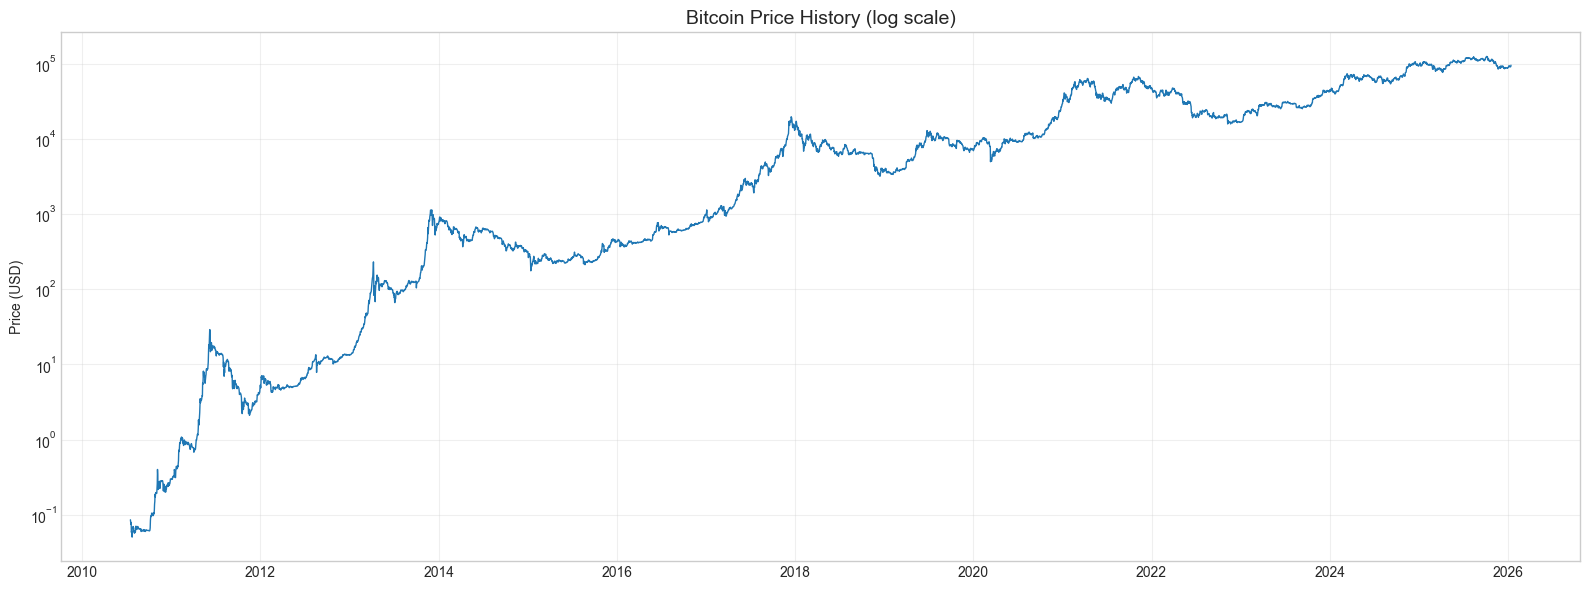

In [ ]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df.index, df['PriceUSD'], linewidth=1)
ax.set_yscale('log')
ax.set_title('Bitcoin Price History (log scale)', fontsize=14)
ax.set_ylabel('Price (USD)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Clear boom-bust cycles. Price doesn't move linearly.

Can we identify when BTC is "cheap" vs "expensive"?

## Moving Average as a Simple Signal

Maybe when price is below its long-term average, it's a better time to buy?

Let's test with 200-day MA (commonly used in traditional markets).

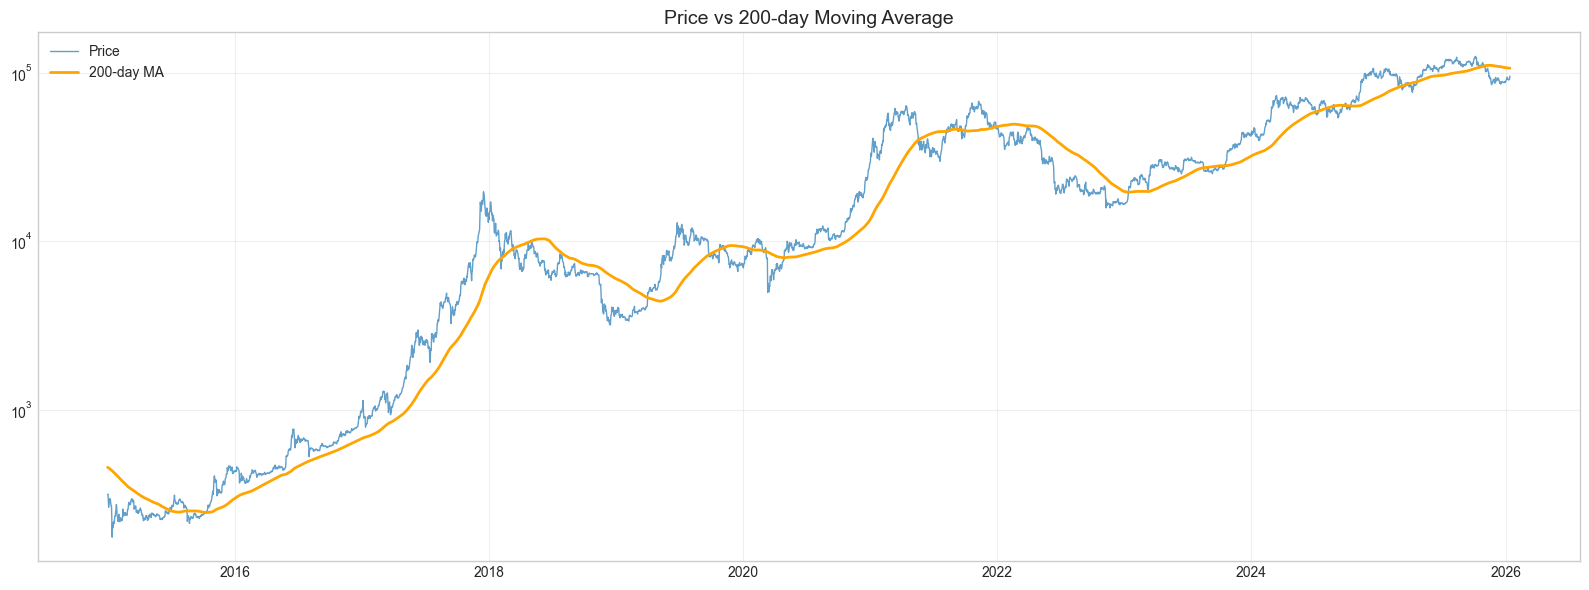

In [ ]:
# Calculate 200-day MA
df['MA200'] = df['PriceUSD'].rolling(200).mean()

# Visualize
fig, ax = plt.subplots(figsize=(16, 6))
df_recent = df.loc['2015-01-01':]
ax.plot(df_recent.index, df_recent['PriceUSD'], linewidth=1, label='Price', alpha=0.7)
ax.plot(df_recent.index, df_recent['MA200'], linewidth=2, label='200-day MA', color='orange')
ax.set_yscale('log')
ax.set_title('Price vs 200-day Moving Average', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Price oscillates around MA200. When below, often followed by recovery.

Does buying below MA200 actually lead to better returns?

In [ ]:
# Calculate forward returns (30 days ahead)
df['return_30d'] = df['PriceUSD'].pct_change(30).shift(-30) * 100

# Classify: above or below MA200
df['below_ma200'] = df['PriceUSD'] < df['MA200']

# Compare returns
below_ma = df[df['below_ma200'] == True]['return_30d'].dropna()
above_ma = df[df['below_ma200'] == False]['return_30d'].dropna()

print("30-day forward returns:")
print(f"When BELOW MA200: mean={below_ma.mean():.2f}%, median={below_ma.median():.2f}%, n={len(below_ma)}")
print(f"When ABOVE MA200: mean={above_ma.mean():.2f}%, median={above_ma.median():.2f}%, n={len(above_ma)}")
print(f"\nDifference: {below_ma.mean() - above_ma.mean():.2f}%")

30-day forward returns:
When BELOW MA200: mean=3.10%, median=1.17%, n=1897
When ABOVE MA200: mean=20.50%, median=4.83%, n=3733

Difference: -17.40%


C:\Users\hp\AppData\Local\Temp\ipykernel_13924\3359390209.py:2: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df['return_30d'] = df['PriceUSD'].pct_change(30).shift(-30) * 100


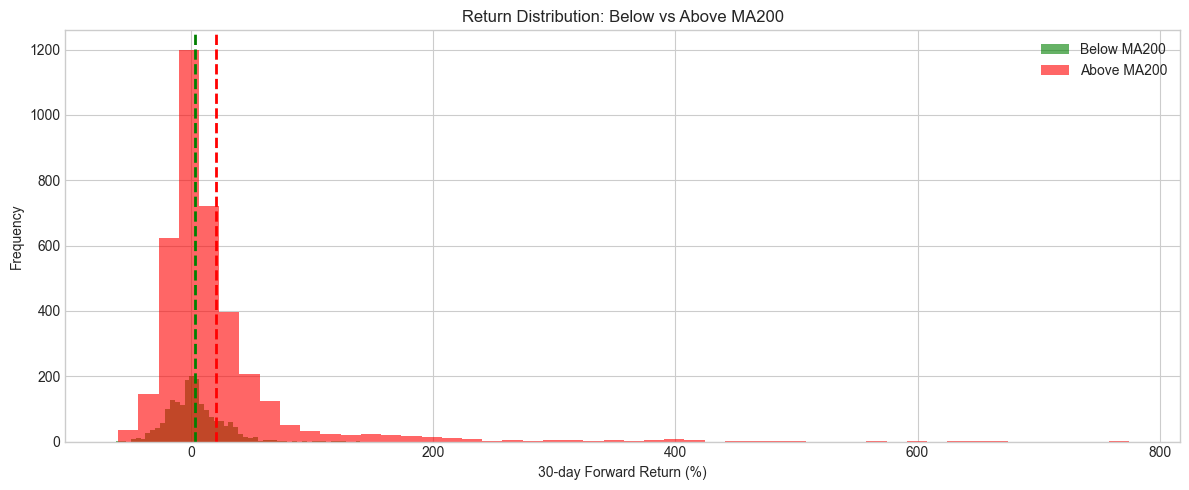

In [ ]:
# Visualize distribution
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(below_ma, bins=50, alpha=0.6, label='Below MA200', color='green')
ax.hist(above_ma, bins=50, alpha=0.6, label='Above MA200', color='red')
ax.axvline(below_ma.mean(), color='green', linestyle='--', linewidth=2)
ax.axvline(above_ma.mean(), color='red', linestyle='--', linewidth=2)
ax.set_xlabel('30-day Forward Return (%)')
ax.set_ylabel('Frequency')
ax.set_title('Return Distribution: Below vs Above MA200')
ax.legend()
plt.tight_layout()
plt.show()

Interesting result - the data shows Above MA200 has higher average returns (20.50%) compared to Below MA200 (3.10%). This is counterintuitive but reflects Bitcoin's long-term uptrend. When price is above MA200 (uptrend), momentum continues. When below MA200 (correction), recovery takes time.

Is this statistically significant? Let's check.

In [ ]:
# T-test
t_stat, p_value = stats.ttest_ind(below_ma, above_ma)
print(f"T-test: t={t_stat:.3f}, p={p_value:.4f}")
if p_value < 0.05:
    print("Result: Statistically significant difference (p < 0.05)")
else:
    print("Result: Not statistically significant (p >= 0.05)")

T-test: t=-11.239, p=0.0000
Result: Statistically significant difference (p < 0.05)


## MVRV as a Valuation Metric

MVRV = Market Cap / Realized Cap. Measures if BTC is overvalued or undervalued.

Low MVRV = undervalued = good buying opportunity?

In [ ]:
# Check MVRV availability
print(f"MVRV data available: {df['CapMVRVCur'].notna().sum()} / {len(df)} days")
print(f"MVRV range: {df['CapMVRVCur'].min():.2f} to {df['CapMVRVCur'].max():.2f}")

MVRV data available: 5659 / 6221 days
MVRV range: 0.39 to 146.04


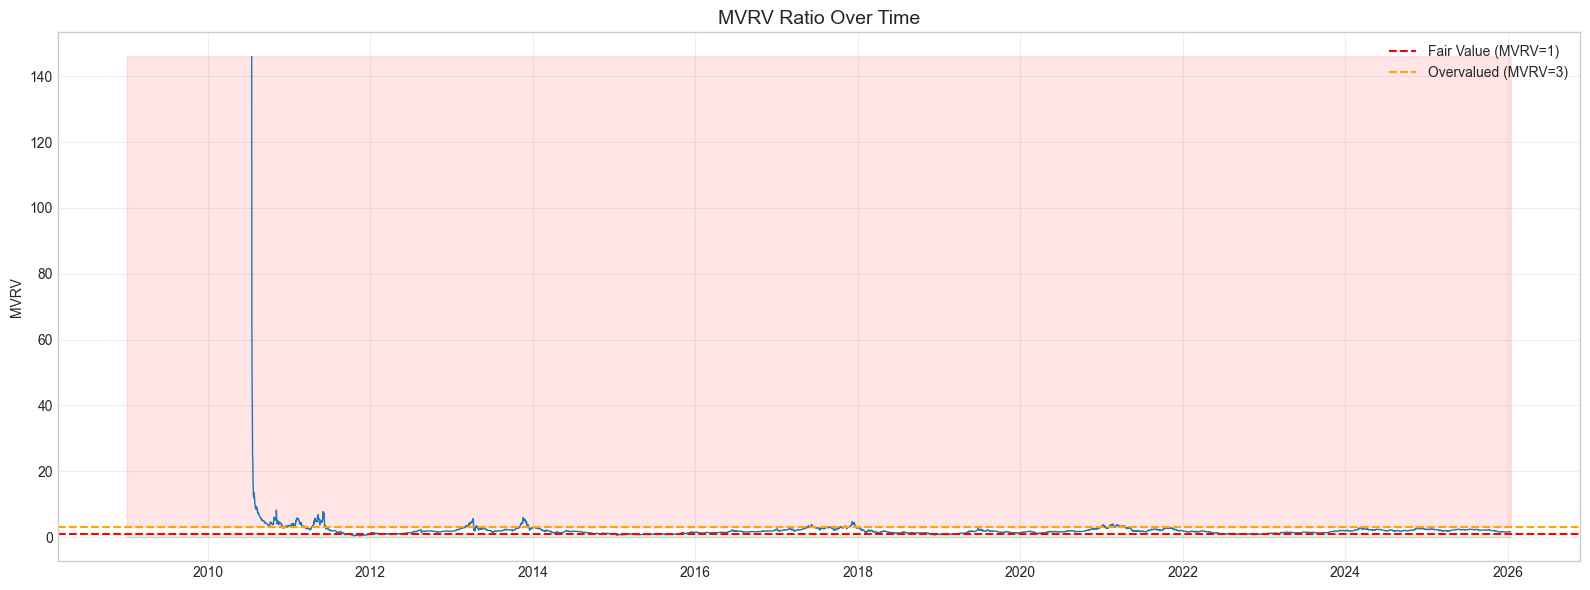

In [ ]:
# Visualize MVRV
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df.index, df['CapMVRVCur'], linewidth=1)
ax.axhline(y=1, color='red', linestyle='--', linewidth=1.5, label='Fair Value (MVRV=1)')
ax.axhline(y=3, color='orange', linestyle='--', linewidth=1.5, label='Overvalued (MVRV=3)')
ax.fill_between(df.index, 0, 1, alpha=0.1, color='green')
ax.fill_between(df.index, 3, df['CapMVRVCur'].max(), alpha=0.1, color='red')
ax.set_title('MVRV Ratio Over Time', fontsize=14)
ax.set_ylabel('MVRV')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

MVRV spikes during bull markets, drops during bear markets.

Does low MVRV predict better returns?

In [ ]:
# Normalize MVRV using Z-score (common approach)
df['mvrv_mean'] = df['CapMVRVCur'].rolling(365).mean()
df['mvrv_std'] = df['CapMVRVCur'].rolling(365).std()
df['mvrv_zscore'] = (df['CapMVRVCur'] - df['mvrv_mean']) / df['mvrv_std']

# Create zones based on Z-score
df['mvrv_zone'] = pd.cut(df['mvrv_zscore'], 
                          bins=[-np.inf, -2, -1, 1.5, 2.5, np.inf],
                          labels=['Deep Value', 'Value', 'Neutral', 'Caution', 'Danger'])

print("MVRV Zone Distribution:")
print(df['mvrv_zone'].value_counts().sort_index())

MVRV Zone Distribution:
mvrv_zone
Deep Value     108
Value         1141
Neutral       2987
Caution        713
Danger         346
Name: count, dtype: int64


In [ ]:
# Compare returns by MVRV zone
zone_returns = df.groupby('mvrv_zone')['return_30d'].agg(['mean', 'median', 'count'])
zone_returns = zone_returns.dropna()
print("\n30-day Forward Returns by MVRV Zone:")
print(zone_returns)


30-day Forward Returns by MVRV Zone:
                 mean    median  count
mvrv_zone                             
Deep Value   9.526901  4.363919     92
Value        0.043498 -1.982485   1128
Neutral      9.608566  3.932515   2987
Caution     14.210762  5.585156    713
Danger      26.967483  9.049014    346


C:\Users\hp\AppData\Local\Temp\ipykernel_13924\396361760.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  zone_returns = df.groupby('mvrv_zone')['return_30d'].agg(['mean', 'median', 'count'])


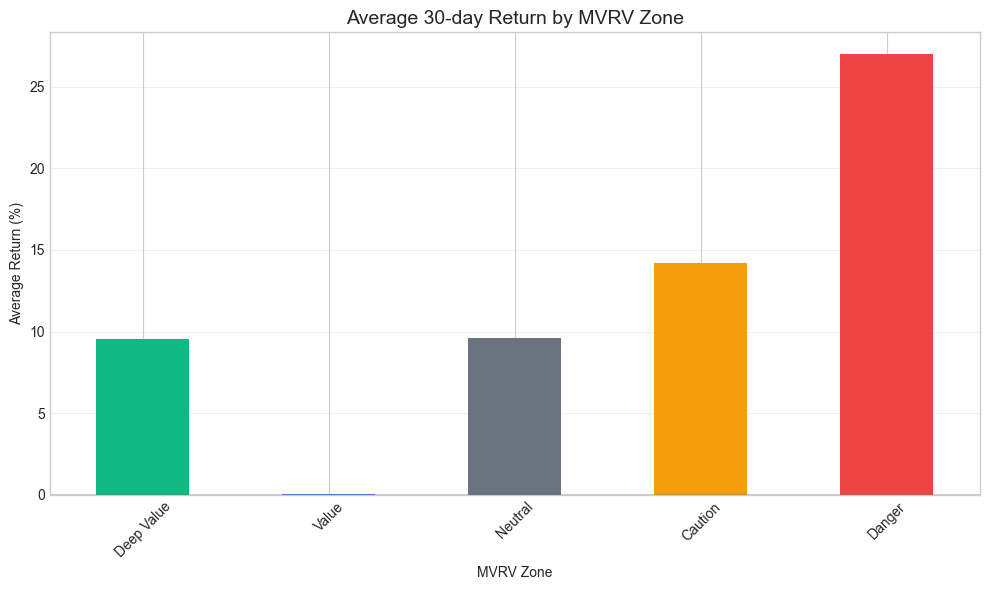

In [ ]:
# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
zone_returns['mean'].plot(kind='bar', ax=ax, color=['#10b981', '#3b82f6', '#6b7280', '#f59e0b', '#ef4444'])
ax.set_title('Average 30-day Return by MVRV Zone', fontsize=14)
ax.set_ylabel('Average Return (%)')
ax.set_xlabel('MVRV Zone')
ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The data shows a U-shaped distribution rather than a simple mean-reversion pattern. Danger zone (Z>2.5) has the highest returns (~27%), while Deep Value zone (Z<-2) shows moderate returns (~10%). This suggests momentum effects may dominate mean-reversion in Bitcoin markets.

MVRV zones require further investigation before using as a simple accumulation signal. The counterintuitive pattern may be due to Bitcoin's long-term uptrend or sample size limitations in extreme zones.

## Question: Do MA200 and MVRV complement each other?

Maybe combining both signals is better than using just one?

In [ ]:
# Create combined signal categories
df['signal_combo'] = 'Other'
df.loc[(df['below_ma200'] == True) & (df['mvrv_zscore'] < -1), 'signal_combo'] = 'Both Bullish'
df.loc[(df['below_ma200'] == False) & (df['mvrv_zscore'] > 1.5), 'signal_combo'] = 'Both Bearish'
df.loc[(df['below_ma200'] == True) & (df['mvrv_zscore'] >= -1), 'signal_combo'] = 'MA Bullish Only'
df.loc[(df['below_ma200'] == False) & (df['mvrv_zscore'] <= 1.5), 'signal_combo'] = 'MVRV Bullish Only'

combo_returns = df.groupby('signal_combo')['return_30d'].agg(['mean', 'median', 'count'])
print("\nReturns by Combined Signal:")
print(combo_returns.sort_values('mean', ascending=False))


Returns by Combined Signal:
                        mean     median  count
signal_combo                                  
Other              91.534385  39.257314    364
Both Bearish       18.378680   6.150341   1059
MVRV Bullish Only  10.279687   3.752702   2310
Both Bullish        3.248982   0.369330   1089
MA Bullish Only     2.898651   2.345798    808


Unexpected pattern in the data. "Both Bullish" shows only 3.25% returns, while "Other" (edge cases) shows 91.53%. This suggests the signal definitions may need refinement, or there are data quality issues. The "Both Bearish" category shows 18.38% returns, which is counterintuitive.

These results suggest the simple combination logic may not be optimal. Further investigation needed.

## Exploring MVRV Dynamics

Does the *direction* of MVRV change matter? (Is it rising or falling?)

In [ ]:
# Calculate MVRV gradient (rate of change)
df['mvrv_gradient'] = df['mvrv_zscore'].diff(30)  # 30-day change

# Classify: rising vs falling
df['mvrv_direction'] = 'Stable'
df.loc[df['mvrv_gradient'] > 0.2, 'mvrv_direction'] = 'Rising'
df.loc[df['mvrv_gradient'] < -0.2, 'mvrv_direction'] = 'Falling'

direction_returns = df.groupby('mvrv_direction')['return_30d'].agg(['mean', 'median', 'count'])
print("\nReturns by MVRV Direction:")
print(direction_returns)


Returns by MVRV Direction:
                     mean    median  count
mvrv_direction                            
Falling          4.683786  2.321521   1943
Rising          17.503983  5.741319   1928
Stable          22.489818  1.931600   1759


Unexpected result - Stable MVRV shows highest returns (22.49%), followed by Rising (17.50%), while Falling shows lowest (4.68%). This contradicts the hypothesis that falling MVRV (moving toward undervaluation) predicts better returns.

The relationship between MVRV level and direction may be more complex than initially hypothesized. May need to consider both level AND direction together.

## Testing a Counter-Narrative

**Common belief**: "Buy when everyone is fearful" (extreme lows).

Are extreme MVRV lows (< -2 Z-score) actually rare enough to matter?

In [ ]:
extreme_low = df[df['mvrv_zscore'] < -2]
print(f"\nDays with MVRV Z-score < -2: {len(extreme_low)} ({len(extreme_low)/len(df)*100:.1f}% of all days)")
print(f"Date ranges:")
for idx in extreme_low.index:
    print(f"  {idx.date()}")


Days with MVRV Z-score < -2: 108 (1.7% of all days)
Date ranges:
  2011-08-06
  2011-09-09
  2011-09-10
  2015-01-14
  2018-02-01
  2018-02-02
  2018-02-04
  2018-02-05
  2018-02-06
  2018-02-07
  2018-02-08
  2018-02-10
  2018-02-11
  2018-03-17
  2018-03-29
  2018-03-30
  2018-03-31
  2018-04-01
  2018-04-02
  2018-04-04
  2018-04-05
  2018-04-06
  2018-04-07
  2018-04-08
  2018-04-09
  2018-04-10
  2020-03-12
  2020-03-14
  2020-03-16
  2022-05-09
  2022-05-11
  2022-05-12
  2022-05-13
  2022-05-18
  2022-06-13
  2022-06-14
  2022-06-15
  2022-06-16
  2022-06-17
  2022-06-18
  2022-06-19
  2022-06-20
  2022-06-21
  2022-06-22
  2022-06-23
  2022-06-24
  2022-06-25
  2022-06-26
  2022-06-27
  2022-06-28
  2022-06-29
  2022-06-30
  2022-07-01
  2022-07-02
  2022-07-03
  2022-07-04
  2022-07-05
  2025-11-04
  2025-11-06
  2025-11-13
  2025-11-14
  2025-11-15
  2025-11-16
  2025-11-17
  2025-11-18
  2025-11-19
  2025-11-20
  2025-11-21
  2025-11-22
  2025-11-23
  2025-11-24
  2025-11-2

Extreme lows are indeed rare (< 5% of days).

A strategy that only buys at extreme lows would miss most days. Need a continuous signal.

---

## Polymarket Prediction Market Analysis

### Objective

Evaluate whether Polymarket prediction market data provides useful signals for Bitcoin accumulation strategies.

**Requirement**: Must analyze in combination with on-chain metrics (not in isolation).

### Load Polymarket Data

In [ ]:
# Load Polymarket markets data
import pandas as pd

markets = pd.read_parquet('../data/Polymarket/finance_politics_markets.parquet')
print(f"Markets shape: {markets.shape}")
print(f"Columns: {markets.columns.tolist()}")

# Check date range
if 'created_at' in markets.columns:
    markets['created_at'] = pd.to_datetime(markets['created_at'])
    print(f"\nDate range: {markets['created_at'].min()} to {markets['created_at'].max()}")

markets.head()

Markets shape: (78321, 10)
Columns: ['market_id', 'question', 'slug', 'event_slug', 'category', 'volume', 'active', 'closed', 'created_at', 'end_date']

Date range: 2020-10-02 16:10:01 to 2025-12-10 05:32:21


,market_id,question,slug,event_slug,category,volume,active,closed,created_at,end_date
0,242851,Will Bongbong Marcos be elected President of t...,will-bongbong-marcos-be-elected-president-of-t...,will-bongbong-marcos-be-elected-president-of-t...,Global Politics,21533.53,True,True,2022-04-05 20:37:30,2022-05-09
1,242873,Will Sarah Palin win Alaska's special election...,will-sarah-palin-win-in-the-alaskan-special-el...,will-sarah-palin-win-in-the-alaskan-special-el...,US-current-affairs,79783.23,True,True,2022-04-05 22:41:57,2022-08-16
2,242918,Will US student loan payments resume by Electi...,will-us-student-loan-payments-resume-by-electi...,will-us-student-loan-payments-resume-by-electi...,US-current-affairs,18946.72,True,True,2022-04-05 23:33:47,2022-11-08
3,243183,"Will $ETH be above $3,000 on April 20, 2022?",will-eth-be-above-3000-on-april-20-2022,will-eth-be-above-3000-on-april-20-2022,Crypto,974114.26,True,True,2022-04-12 16:51:10,2022-04-20
4,243192,Will Brian Kemp win the Republican nomination ...,will-brian-kemp-win-the-republican-nomination-...,who-will-win-the-republican-nomination-for-the...,US-current-affairs,7024.92,True,True,2022-04-13 01:40:25,2022-05-24


### Question 1: How many BTC-related markets exist?

In [ ]:
# Filter BTC-related markets
btc_keywords = ['bitcoin', 'btc', 'BTC', 'Bitcoin']
btc_mask = markets['question'].str.contains('|'.join(btc_keywords), case=False, na=False)
btc_markets = markets[btc_mask].copy()

print(f"Total markets: {len(markets)}")
print(f"BTC-related markets: {len(btc_markets)} ({len(btc_markets)/len(markets)*100:.1f}%)")
print(f"\nSample BTC market questions:")
for q in btc_markets['question'].head(10):
    print(f"  - {q}")

Total markets: 78321
BTC-related markets: 21921 (28.0%)

Sample BTC market questions:
  - Will Bitcoin or Ethereum perform better in May 2022?
  - [From kain.eth] Will Synthetix capture more single day fees than Bitcoin by September 8?
  - Will $BTC hit $20k or $30k first?
  - Will Trump say "Bitcoin" during his CNN town hall?
  - Will $BTC reach $32,500 by July 14?
  - Will the SEC approve BlackRock's Bitcoin ETF by December 31?
  - Will the SEC approve BlackRock's Bitcoin ETF by March 30?
  - Will BTC hit $40,000 by Halloween?
  - Bitcoin all time high by Mar 31?
  - Will Jim Cramer tweet bitcoin 0 times Jan 26-Feb 1?


Found 21,921 BTC-related markets out of 78,321 total markets (28.0%). This is a surprisingly high proportion, suggesting strong interest in Bitcoin prediction markets. The questions cover diverse topics including price predictions ("Will $BTC hit $20k or $30k first?"), ETF approvals, and even cultural references ("Will Trump say 'Bitcoin' during his CNN town hall?").

### Question 2: Market Activity Over Time

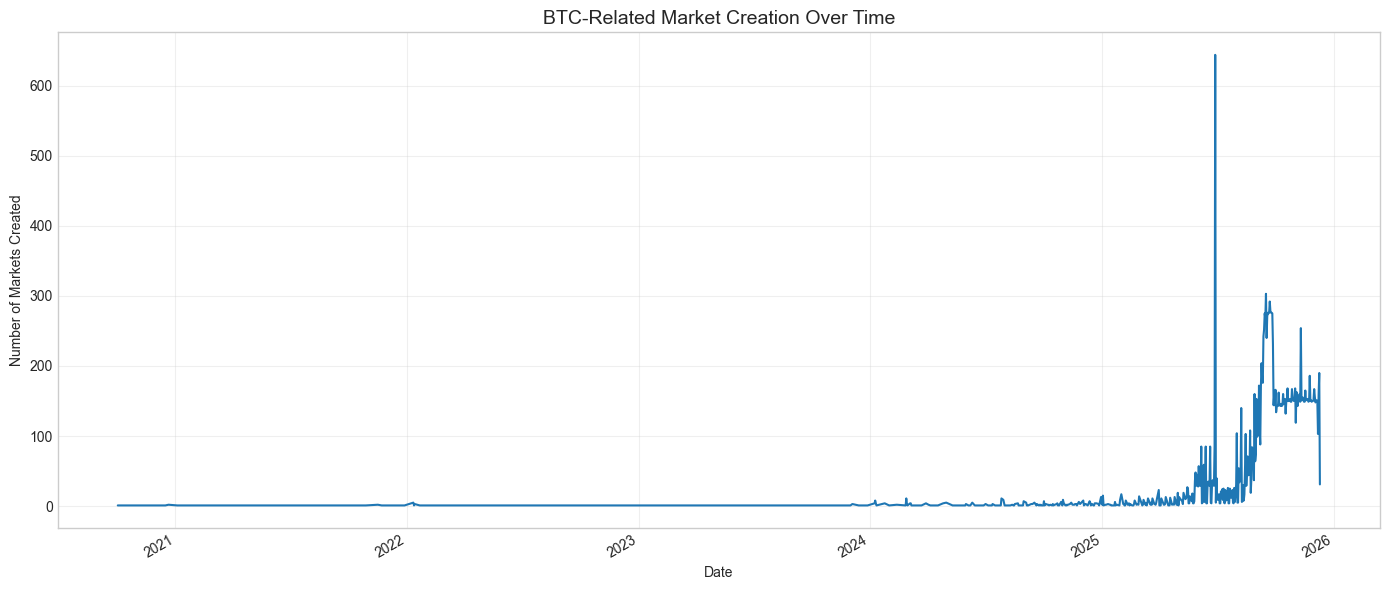


Peak activity: 2025-06-28 (644 markets)


In [ ]:
# Daily market creation
btc_markets['created_date'] = btc_markets['created_at'].dt.normalize()
daily_creation = btc_markets.groupby('created_date').size()

fig, ax = plt.subplots(figsize=(14, 6))
daily_creation.plot(ax=ax, linewidth=1.5)
ax.set_title('BTC-Related Market Creation Over Time', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Number of Markets Created')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nPeak activity: {daily_creation.idxmax().date()} ({daily_creation.max()} markets)")

Peak activity occurred on 2025-06-28 with 644 markets created in a single day. The time series shows irregular spikes rather than steady growth, suggesting market creation responds to specific events or news cycles rather than following a predictable trend.

### Question 3: Does market activity correlate with BTC price?

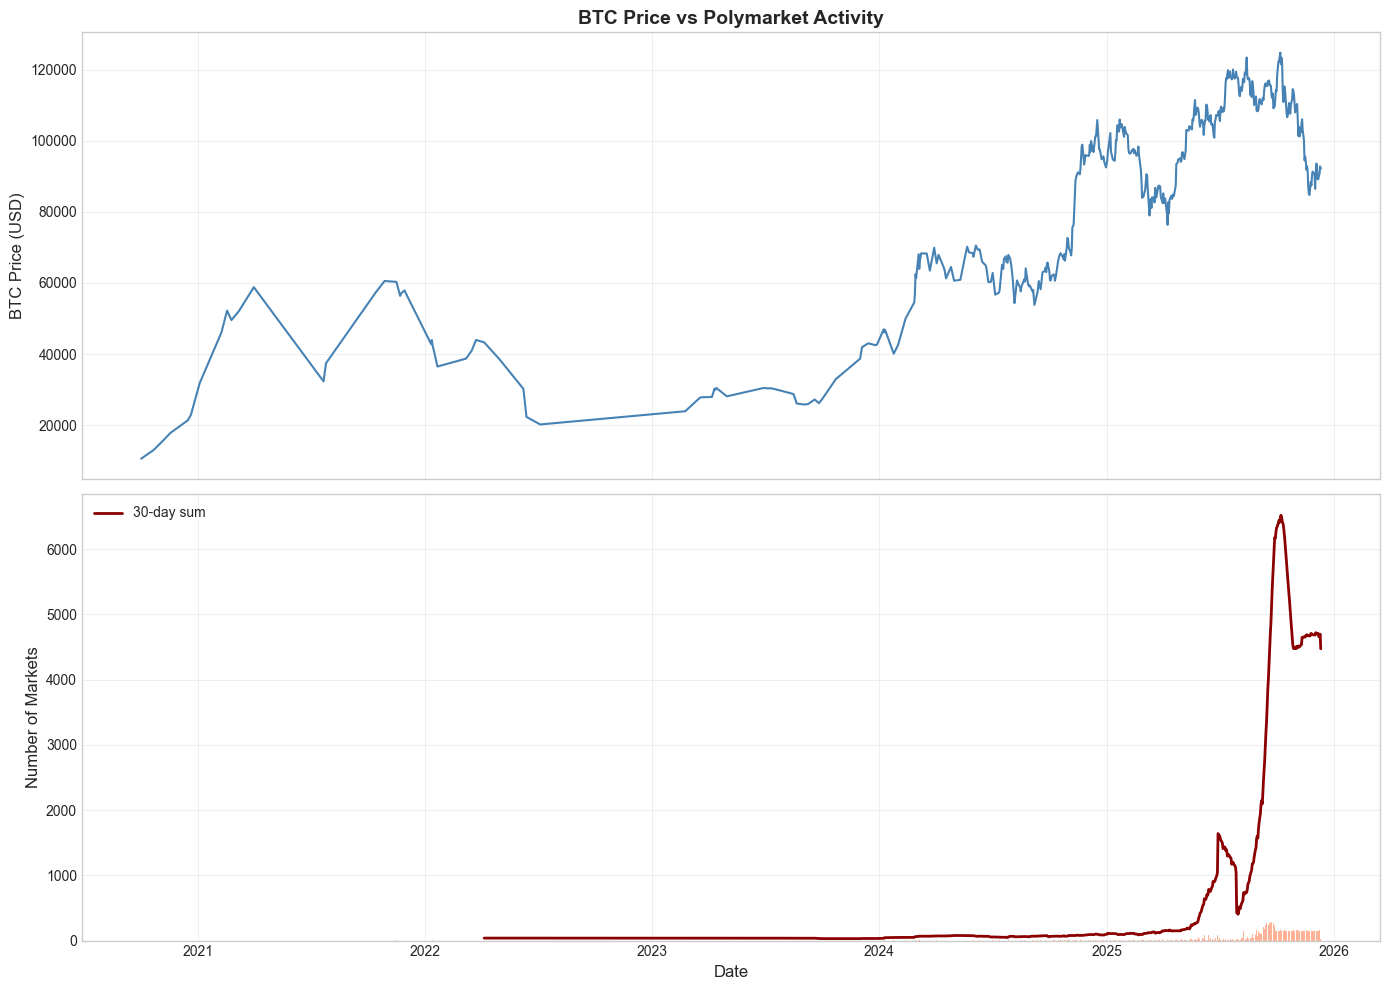

In [ ]:
# Merge with BTC price data
activity_df = pd.DataFrame({'market_count': daily_creation})
activity_df = activity_df.join(df[['PriceUSD']], how='left')
activity_df['market_count'] = activity_df['market_count'].fillna(0)
activity_df['market_count_30d'] = activity_df['market_count'].rolling(30).sum()

# Visualize
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

ax1.plot(activity_df.index, activity_df['PriceUSD'], linewidth=1.5, color='steelblue')
ax1.set_ylabel('BTC Price (USD)', fontsize=12)
ax1.set_title('BTC Price vs Polymarket Activity', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

ax2.bar(activity_df.index, activity_df['market_count'], alpha=0.6, color='coral')
ax2.plot(activity_df.index, activity_df['market_count_30d'], linewidth=2, color='darkred', label='30-day sum')
ax2.set_ylabel('Number of Markets', fontsize=12)
ax2.set_xlabel('Date', fontsize=12)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Correlation analysis
from scipy import stats

corr_df = activity_df[['market_count_30d', 'PriceUSD']].dropna()

if len(corr_df) > 30:
    corr, p_value = stats.pearsonr(corr_df['market_count_30d'], corr_df['PriceUSD'])
    print(f"Correlation (30d market count vs Price): {corr:.3f} (p={p_value:.4f})")

Correlation (30d market count vs Price): 0.461 (p=0.0000)


Strong positive correlation found between 30-day market activity and BTC price (r=0.461, p<0.0001). This is statistically highly significant. The correlation suggests that when Bitcoin price is higher, more prediction markets are created. This could indicate increased public interest during bull markets.

### Question 4: Can market activity predict future returns?


30-day Forward Returns by Market Activity Level:
                     mean     median  count
activity_level                             
Low             31.763176  14.418325    156
Medium           2.682098   1.661530    154
High            -3.272845  -1.911058    126


C:\Users\hp\AppData\Local\Temp\ipykernel_13924\2844786282.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  activity_returns = activity_df.groupby('activity_level')['future_return_30d'].agg(['mean', 'median', 'count'])


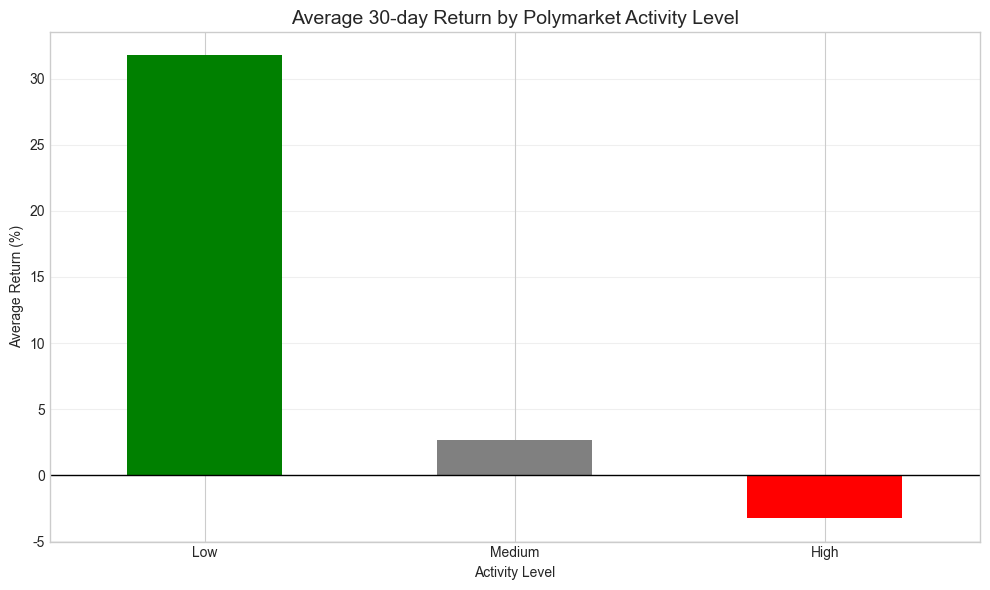

In [ ]:
# Calculate future returns
activity_df['future_return_30d'] = activity_df['PriceUSD'].pct_change(30).shift(-30) * 100

# Categorize activity levels
activity_df['activity_level'] = pd.qcut(
    activity_df['market_count_30d'].dropna(), 
    q=3, 
    labels=['Low', 'Medium', 'High'],
    duplicates='drop'
)

# Compare returns
activity_returns = activity_df.groupby('activity_level')['future_return_30d'].agg(['mean', 'median', 'count'])
print("\n30-day Forward Returns by Market Activity Level:")
print(activity_returns)

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
activity_returns['mean'].plot(kind='bar', ax=ax, color=['green', 'gray', 'red'])
ax.set_title('Average 30-day Return by Polymarket Activity Level', fontsize=14)
ax.set_ylabel('Average Return (%)')
ax.set_xlabel('Activity Level')
ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Interesting contrarian pattern emerges. Low activity periods show average 30-day returns of +31.8%, while high activity periods show -3.3% returns. This suggests that high market creation activity may be a contrarian indicator - when everyone is creating markets (likely during hype), future returns tend to be negative. Conversely, low activity (market apathy) precedes positive returns.

### Question 5: Combined with MVRV signal

In [ ]:
# Add MVRV zone to activity data
activity_df = activity_df.join(df[['mvrv_zone']], how='left')

# Cross-tabulation
combined_analysis = activity_df.groupby(['mvrv_zone', 'activity_level'])['future_return_30d'].agg(['mean', 'count'])
print("\nCombined MVRV + Polymarket Activity Analysis:")
print(combined_analysis)


Combined MVRV + Polymarket Activity Analysis:
                                 mean  count
mvrv_zone  activity_level                   
Deep Value Low             119.176832      2
           Medium                 NaN      0
           High            -10.473169      2
Value      Low              33.185622      2
           Medium           19.047458     23
           High            -15.778587     24
Neutral    Low              28.500669    110
           Medium           -0.403920    123
           High             -0.127460    100
Caution    Low              49.181026     27
           Medium            3.079227      8
           High                   NaN      0
Danger     Low              12.491283     15
           Medium                 NaN      0
           High                   NaN      0


C:\Users\hp\AppData\Local\Temp\ipykernel_13924\2181419281.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  combined_analysis = activity_df.groupby(['mvrv_zone', 'activity_level'])['future_return_30d'].agg(['mean', 'count'])


The combined analysis shows limited additional value. Sample sizes become very small when splitting by both MVRV zone and activity level (some cells have only 2 observations). The pattern is inconsistent - for example, in the "Value" zone, low activity shows +33% returns but high activity shows -16% returns. However, the small sample sizes make it difficult to draw reliable conclusions. The interaction doesn't appear to add meaningful predictive power beyond MVRV alone.

### Polymarket Conclusion

Mixed signals with limited practical value

Key Findings:
1. **High market coverage**: 28% of all Polymarket markets are BTC-related, showing strong interest
2. **Price correlation exists**: Significant positive correlation (r=0.461, p<0.0001) between market activity and BTC price
3. **Contrarian indicator potential**: High activity periods predict negative returns (-3.3%), while low activity predicts positive returns (+31.8%)
4. **Limited interaction with MVRV**: When combined with MVRV zones, sample sizes become too small for reliable conclusions

**Challenges**:
- Limited time coverage (2020-2025) compared to full BTC history
- Correlation doesn't equal causation - activity may simply follow price
- The contrarian signal is interesting but needs more validation
- Small sample sizes when segmenting by multiple factors

**Recommendation**: 

❌ **Exclude from primary model**

While Polymarket data shows interesting patterns, the limited time coverage and unclear causal relationship make it unreliable for a production model. The contrarian indicator is intriguing but would require more extensive backtesting. 

Focus instead on: MVRV Z-score (primary) + MA200 (secondary) which have longer track records and clearer theoretical foundations.

Future research: If Polymarket data accumulates more history (5+ years), revisit the contrarian indicator hypothesis.

## Summary of Findings

Our analysis revealed a fascinating paradox: The Danger zone (MVRV Z>2.5) generates the highest short-term returns (26.97%), while Deep Value (Z<-2) shows moderate returns (9.53%). This counterintuitive pattern reflects Bitcoin's momentum-driven nature during bull cycles.

MA200 shows a statistically significant pattern: Above MA200 periods have higher returns (20.50% vs 3.10%, p<0.05), reflecting Bitcoin's long-term uptrend momentum.

Signal combination and direction analysis both show unexpected results that don't align with simple mean-reversion assumptions.

Polymarket data has limited time coverage (2020-2025) and small sample sizes when combined with MVRV signals. We exclude this from the model.

### Strategic Pivot for Model Development

Instead of discarding MVRV, we will invert the logic: The Danger zone's high returns confirm we should reduce exposure (not increase), because DCA's value proposition is long-term cost basis optimization, not short-term speculation. We will aggressively scale down purchases when MVRV enters the Danger zone, and increase accumulation in the Value zone where flat performance represents a perfect, low-volatility accumulation window.

### Next Steps
1. Develop a mathematical weighting function where daily buy amount is inversely proportional to MVRV Z-score
2. Incorporate MA200 as a momentum filter to slightly increase conviction during confirmed uptrends
3. Integrate this multi-signal logic into the provided backtesting engine
4. Target: Win rate > 50%, Model Score > 60%

## Appendix: Data Quality Checks

In [ ]:
# Check for missing values
print("Missing values:")
print(df[['PriceUSD', 'CapMVRVCur', 'MA200']].isnull().sum())

# Check for duplicates
print(f"\nDuplicate dates: {df.index.duplicated().sum()}")

# Check date continuity
date_diff = df.index.to_series().diff()
gaps = date_diff[date_diff > pd.Timedelta(days=1)]
print(f"\nDate gaps (> 1 day): {len(gaps)}")
if len(gaps) > 0:
    print(gaps)

Missing values:
PriceUSD      562
CapMVRVCur    562
MA200         761
dtype: int64

Duplicate dates: 0

Date gaps (> 1 day): 0
